Partial Sum converges to within 1.0e-08 at mode 7071
The 95.0% capturing mode is 20
[0, 3, 30, 164]


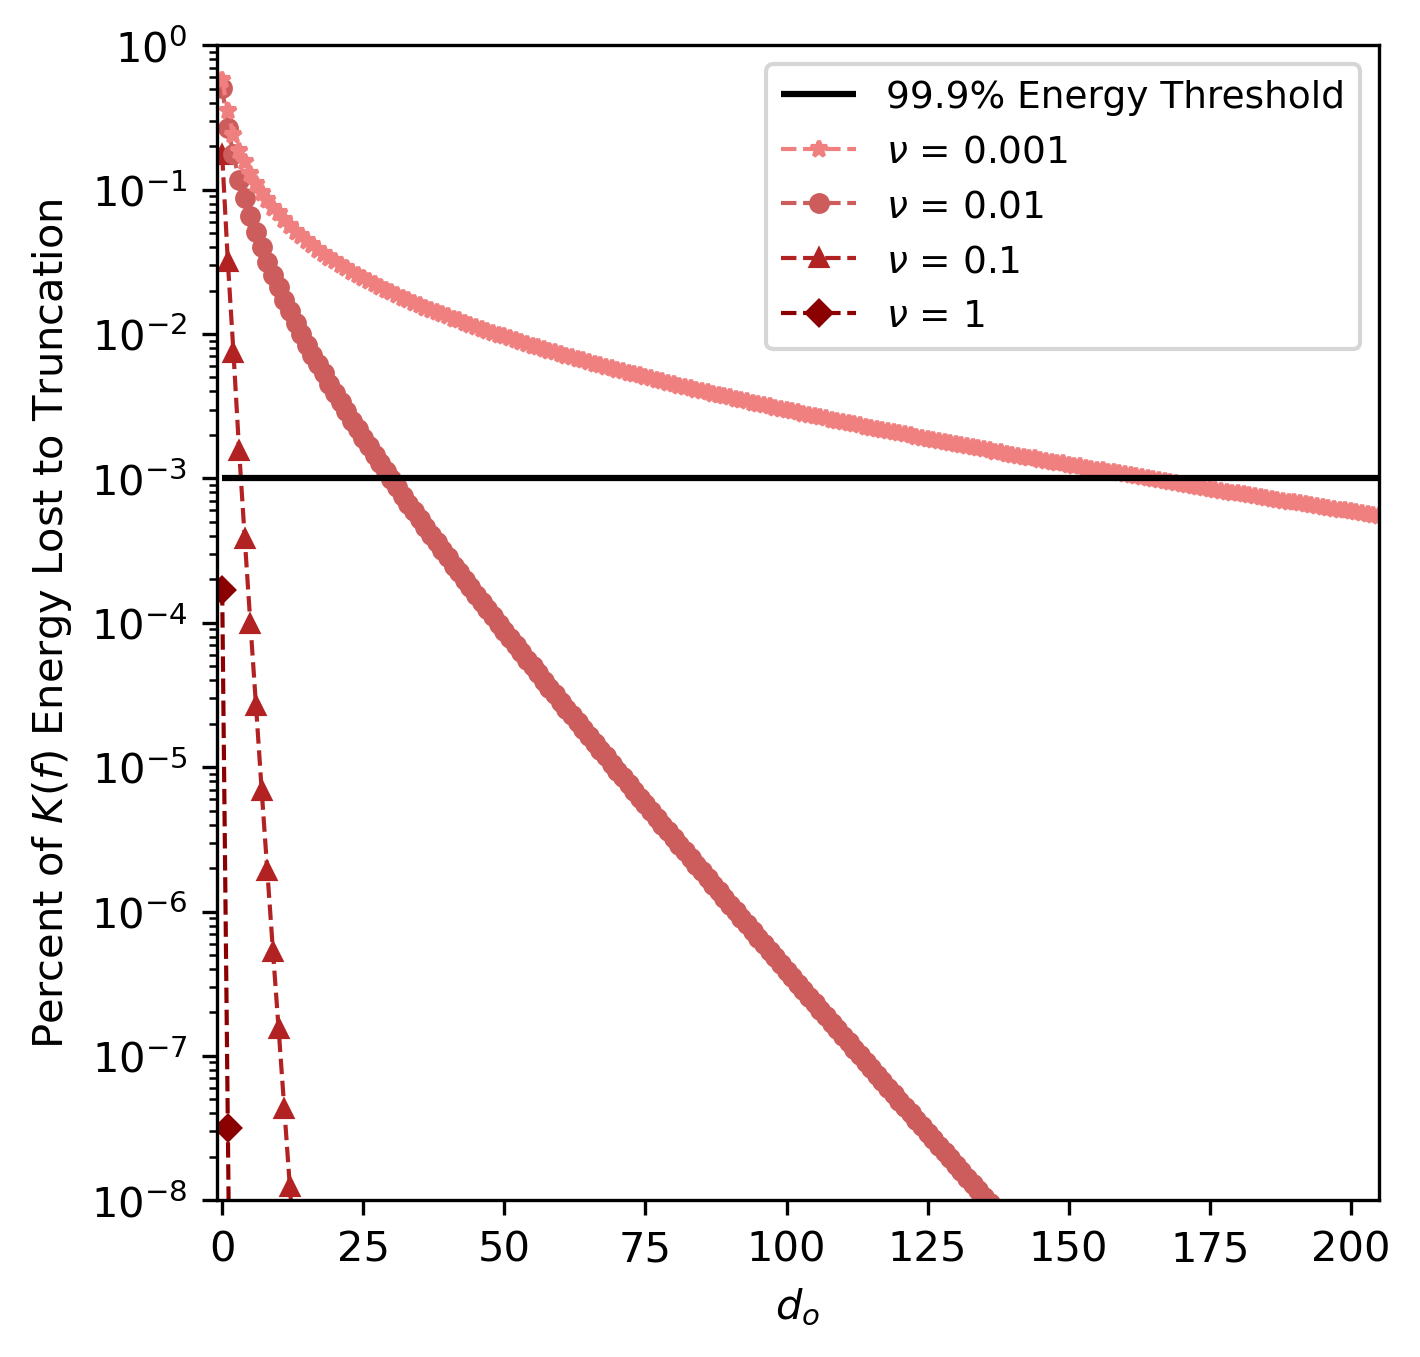

In [1]:
################################################################################################################
###                                          Import Libraries:
################################################################################################################

import sys 
sys.path.insert(0,'../Modules/')
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from Block_WLS import Block_WLS
from Tensor_InducedSamp import Jacobi_Tensor_Induced_Sampling
from jacobi_sampling import jacobi_tensor_samp
from index_set import index_set
from pde_solvers import Viscous_Burgers_Spectral_Galerkin
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300

################################################################################################################
#                                        Input Energy Truncation  
################################################################################################################

#--- Define TP Jacobi distribution for forcing function 
#--- For symmetric jacobi distribution, Var_a = 1/(2a + 3)
#--- Energy of function draw = \sum_{i\in [d]} Var_{a_i}
modes = np.arange(20_000) + 1
jacobi_params = [ [modes[k]**(2),(modes[k]**(2))] for k in range(modes.shape[0])]

Sn = [0]
n = 0
tol = 1e-8
thresh = 0.95
def var(n):
    return (1/(2*np.array(jacobi_params)[:,0][n] + 3))
while True:
    if n == len(jacobi_params) -1:
        print("hit max mode")
        break
    term = var(n)
    if term > tol: 
        Sn.append(Sn[-1] + var(n))
        n+=1
    elif term <= tol:
        print(f"Partial Sum converges to within {tol:.1e} at mode {n}")
        break
Sn = np.array(Sn)

#--- Find thresh% mode:
thresh = 0.95
mode_trunc = np.argmin(np.abs(Sn - thresh*Sn[-1]))
print(f"The {thresh * 100}% capturing mode is {mode_trunc}")

################################################################################################################
#                                       Output Energy Truncation  
################################################################################################################

output_dat = []
for nu in [1,0.1, 0.01, 0.001]:
    induced = True                      
    max_poly_degree = 10             
    input_mode_truncation = mode_trunc      
    output_mode_truncation = 500       
    hc_param = 60                        
                   
    v = nu
    T = 0.2                            
    dt = 0.0001                        
    lift_dim = np.max([10*input_mode_truncation, output_mode_truncation])                 
    def pde_eval(input_data):
        M = input_data.shape[0]
        input_data_lifted = np.zeros([M, lift_dim])
        input_data_lifted[:, :input_mode_truncation] = input_data
        output_data = Viscous_Burgers_Spectral_Galerkin(v, dt, int(T/dt), input_data_lifted)[:, :output_mode_truncation]
        if not np.all(np.isfinite(np.linalg.norm(output_data, axis=1))):
            raise ValueError("Encountered inf/nan while solving PDE. Probably you want to decrease dt")
        return output_data

    jacobi_params = [[a**2,a**2]for a in range(input_mode_truncation)]
    weights = np.linspace(1, 0.01, input_mode_truncation)
    idx_set = index_set(input_mode_truncation, hc_param, max_index=max_poly_degree, weights=weights, max_size=10000, type="hc")    
    N = idx_set.shape[0]
    M = 100

    if induced:
        input_samples = input_samples = Jacobi_Tensor_Induced_Sampling(M, idx_set, jacobi_params, max_poly_degree)
    else: 
        input_samples = jacobi_tensor_samp(jacobi_params, M)
    output_samples = pde_eval(input_samples)
    output_dat.append(output_samples)

###--- Plot 

fig, ax = plt.subplots(figsize =(5,5))
thresh_idxs = []
thresh = 0.999
colors = ["darkred","firebrick","indianred", "lightcoral"]
markers = ["D", "^", "o", "*"]
modes = np.arange(output_mode_truncation)
for i,nu in enumerate([1,0.1, 0.01, 0.001]):
    data = output_dat[i]**2
    tot_out_eng = np.cumsum(np.mean(data, axis = 0))
    part_eng = tot_out_eng/tot_out_eng[-1]
    thresh_idxs.append(np.argmin(np.abs(part_eng - thresh)))
    ax.plot(modes, 1 - part_eng, color = colors[i], marker = markers[i], linestyle = "--", markersize = 4, linewidth = 1, label = rf"$\nu$ = {nu}")
ax.hlines([1-thresh], xmin = 0, xmax = modes[-1], color = 'k', label = f"{100*thresh}% Energy Threshold")
ax.set(yscale='log', 
       ylim = (1e-8,1), 
       xlim = (-1,1.25*np.max(thresh_idxs)),
       xlabel = r"$d_o$", 
       ylabel = r"Percent of $K(f)$ Energy Lost to Truncation")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], loc='best',fontsize = 9)
plt.savefig("Plots/vb_out_truc_err.png", bbox_inches = 'tight')
print(thresh_idxs)

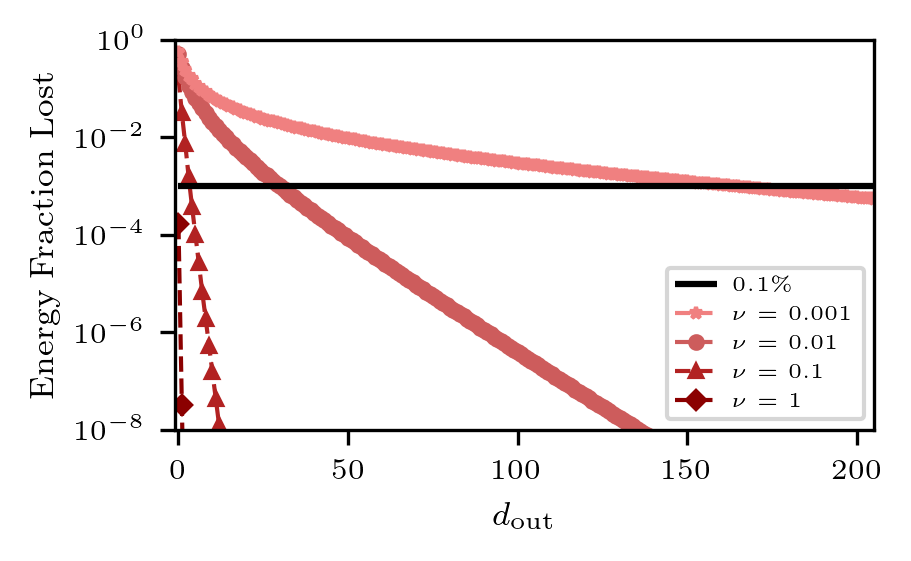

In [8]:
import matplotlib as mpl
import matplotlib.pyplot as plt
# General params 
plt.rcParams["font.size"] = 10
plt.rcParams["font.family"] = "Computer Modern"
plt.rcParams["text.usetex"] = True
plt.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}\usepackage{amssymb}"
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams['savefig.transparent'] = True
plt.rcParams["savefig.format"] = "pdf"
mpl.rcParams['figure.dpi'] = 300

mpl.rcParams["pdf.fonttype"] = 42   # TrueType
mpl.rcParams["ps.fonttype"] = 42

# Set figure sizes 
textwidth_pt = 422.52252                     
pt_to_inch = 1.0 / 72.27
subfig_ratio = 0.5
fig_width = textwidth_pt * pt_to_inch   *subfig_ratio         
fig_height = fig_width * 0.6                     
# Font sizes
base = 7  # match LaTeX \normalsize
plt.rcParams["font.size"] = base
plt.rcParams["axes.labelsize"] = base + 1      
plt.rcParams["axes.titlesize"] = base + 1      
plt.rcParams["xtick.labelsize"] = base         
plt.rcParams["ytick.labelsize"] = base         
plt.rcParams["legend.fontsize"] = base -2        
# Markersizes
markersize_small = 1
linewidth_small = 0.5
markersize_large = 3
linewidth_large = 1


fig, ax = plt.subplots(figsize =(fig_width, fig_height), layout = 'constrained')
thresh_idxs = []
thresh = 0.999
colors = ["darkred","firebrick","indianred", "lightcoral"]
markers = ["D", "^", "o", "*"]
modes = np.arange(output_mode_truncation)
for i,nu in enumerate([1,0.1, 0.01, 0.001]):
    data = output_dat[i]**2
    tot_out_eng = np.cumsum(np.mean(data, axis = 0))
    part_eng = tot_out_eng/tot_out_eng[-1]
    thresh_idxs.append(np.argmin(np.abs(part_eng - thresh)))
    ax.plot(modes, 1 - part_eng, color = colors[i], marker = markers[i], linestyle = "--", markersize = markersize_large, linewidth = linewidth_large, label = rf"$\nu$ = {nu}")
ax.hlines([1-thresh], xmin = 0, xmax = modes[-1], color = 'k', label = r"$0.1\%$")#f"{100*thresh}% Energy Threshold")
ax.set(yscale='log', 
       ylim = (1e-8,1), 
       xlim = (-1,1.25*np.max(thresh_idxs)),
       xlabel = r"$d_{\mathrm{out}}$", 
       ylabel = r"Energy Fraction Lost")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], loc='best')
plt.savefig("Plots/vb_out_truc_err.pdf", bbox_inches = 'tight')